In [9]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# Filter for Data Analyst Data
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# create a new column for month number
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

In [11]:
# explode the job_skills column and pivot
df_DA_exploded =df_DA.explode('job_skills')
df_DA_pivot = df_DA_exploded.pivot_table(
    index='job_posted_month_no',
    columns='job_skills',
    aggfunc='size',
    fill_value=0
)

In [12]:
# sort the skills by count
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

In [13]:
# Use month names for plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(
    lambda x: pd.to_datetime(x, format='%m').strftime('%b')
)
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

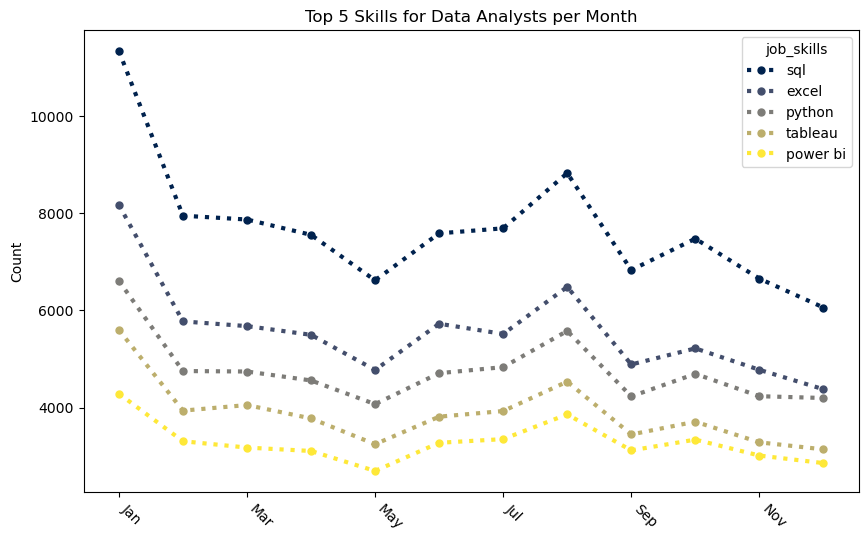

In [32]:
# Get the top 5 skills
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=3,
    linestyle=':',
    colormap='cividis',
    marker='o',
    markersize=5,
    figsize=(10,6)
)

plt.title('Top 5 Skills for Data Analysts per Month')
plt.xticks(rotation=-45, ha='left')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

In [ ]:
# Expolde
df_skills = df_DA.explode('job_skills')

# Calculate the average salary and job count of job postings per skill, and limit top skills
top_skills = 20
skills_count = df_skills.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('salary_year_avg', 'size')
).sort_values(by='skill_count', ascending=False).head(top_skills)

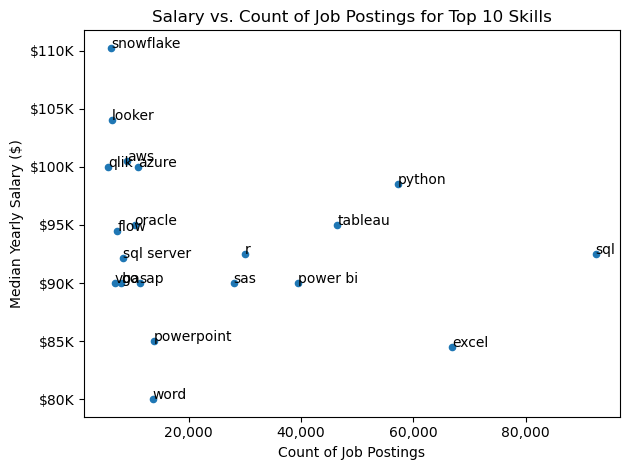

In [39]:
skills_count.plot(kind='scatter', x='skill_count', y='median_salary')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda  y, pos: f'${int(y/1000)}K'
))
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, pos: f'{int(x):,}'
))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()

for i, txt in enumerate(skills_count.index):
    plt.text(
        skills_count['skill_count'].iloc[i],
        skills_count['median_salary'].iloc[i],
        txt
    )

plt.show()

In [ ]:
from adjustText import adjust_Text